# 0. Carga de datos brutos

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
sys.path.append(os.path.abspath('..'))

In [3]:
import pandas as pd
import numpy as np
import xgboost as xgb
import geopandas as gpd
from shapely import wkt
from google.cloud import bigquery
import unicodedata

from pre_procesado.common_pipeline import run_global_pipeline
from pre_procesado.non_linear_coldstart_pipeline import create_neighborhood_momentum_features
from utils_entrenamiento import walk_forward_split

from pre_procesado.non_linear_pipeline import build_tree_pipeline
from utils_entrenamiento import evaluate_classification, aggregate_fold_metrics
from utils_entrenamiento import plot_confusion_matrix 

import shap
from tqdm.auto import tqdm 

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

c:\Users\Yannis\anaconda3\envs\project3\lib\site-packages\google\api_core\_python_version_support.py:242: FutureWarning: You are using a non-supported Python version (3.9.25). Google will not post any further updates to google.api_core supporting this Python version. Please upgrade to the latest Python version, or at least Python 3.10, and then update google.api_core.
  warnings.warn(message, FutureWarning)
c:\Users\Yannis\anaconda3\envs\project3\lib\site-packages\google\auth\__init__.py:54: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)
c:\Users\Yannis\anaconda3\envs\project3\lib\site-packages\google\oauth2\__init__.py:40: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-a

In [4]:
client = bigquery.Client(project="project3grupo1")
query = """
WITH listings_dedup AS (
    SELECT *
    FROM `project3grupo1.airbnb_raw.listings`
    QUALIFY ROW_NUMBER() OVER (PARTITION BY id ORDER BY snapshot_date DESC) = 1
),

events_agg AS (
    SELECT 
        start_date,
        COUNTIF(category = 'sports') as num_sports,
        COUNTIF(category = 'festivals') as num_festivals,
        SUM(phq_attendance) as total_attendance
    FROM `project3grupo1.airbnb_features.events`
    GROUP BY start_date
),

holidays_valencia AS (
    SELECT DISTINCT date
    FROM `project3grupo1.airbnb_features.holidays`
    WHERE applies_to_valencia = True
),

calendar_dates AS (
    SELECT DISTINCT date
    FROM `project3grupo1.airbnb_raw.calendar`
),

days_to_holiday AS (
    SELECT
        cd.date,
        MIN(DATE_DIFF(h.date, cd.date, DAY)) as days_to_next_holiday
    FROM calendar_dates cd
    LEFT JOIN holidays_valencia h ON h.date >= cd.date
    GROUP BY cd.date
)

SELECT
    -- Identificadores añadidos
    c.listing_id,

    -- Target
    CASE WHEN c.available = False THEN 1 ELSE 0 END as is_occupied,

    -- Temporales
    c.date,
    EXTRACT(MONTH FROM c.date) as month,
    EXTRACT(DAYOFWEEK FROM c.date) as day_of_week,
    IF(EXTRACT(DAYOFWEEK FROM c.date) IN (1,7), 1, 0) as is_weekend,
    COALESCE(dh.days_to_next_holiday, 0) as days_to_next_holiday,
    IF(h.date IS NOT NULL, 1, 0) as is_holiday,

    -- Del piso
    l.neighbourhood_cleansed,
    l.room_type,
    l.accommodates,
    l.price as listing_price,
    l.minimum_nights,
    l.number_of_reviews,
    l.review_scores_rating,
    IF(l.number_of_reviews > 0, 1, 0) as has_reviews,
    l.instant_bookable,

    -- Meteorología
    w.temp_mean,
    w.precipitation_mm,

    -- Eventos
    COALESCE(e.num_sports, 0) as num_sports,
    COALESCE(e.num_festivals, 0) as num_festivals,
    COALESCE(e.total_attendance, 0) as total_attendance

FROM `project3grupo1.airbnb_raw.calendar` c
LEFT JOIN listings_dedup l ON c.listing_id = l.id
LEFT JOIN `project3grupo1.airbnb_features.weather` w ON c.date = w.date
LEFT JOIN events_agg e ON c.date = e.start_date
LEFT JOIN holidays_valencia h ON c.date = h.date
LEFT JOIN days_to_holiday dh ON c.date = dh.date
WHERE c.date <= '2026-05-19'
QUALIFY ROW_NUMBER() OVER (PARTITION BY c.listing_id, c.date ORDER BY c.date DESC) = 1
"""

df_raw = client.query(query).to_dataframe()
print(f"Datos brutos cargados desde BQ: {df_raw.shape}")

Datos brutos cargados desde BQ: (3376585, 22)


# 1. Bucle de entrenamiento de preprocesado + entrenamiento + evaluación por pliegue temporal

In [5]:
print(" Iniciando Pipeline Global")
df_processed = run_global_pipeline(df_raw, max_lag=14)

print(" Añadiendo features de Cold Start")
df_processed = create_neighborhood_momentum_features(df_processed)

print("\nGenerando particiones temporales (Walk-Forward)")
folds = walk_forward_split(
    df_processed, 
    date_col='date', 
    n_folds=4,
    val_months=1,
    min_train_months=8)


 Iniciando Pipeline Global
🔧 PIPELINE GLOBAL (FASE 1)
[Duplicados] Eliminadas 0 filas (0.00%). Retenidas: 3376585
[MNAR Flags] Creadas 1 variables indicadoras: ['is_missing_review_scores_rating']
[Lags Individuales] Creados 13 lags (2 a 14) sobre 'is_occupied' agrupados por listing_id.
[Rachas] Creadas 'streak_occupied' y 'streak_vacant' con shift(2).
[Barrio Features] Creadas: 'occ_barrio_ayer', 'occ_barrio_ma7', 'price_ratio_barrio'.
[Cíclicas] Creadas 'day_sin' y 'day_cos' a partir de 'day_of_week'.
[Casteo] Variables residuales binarizadas y features numéricas casteadas a float64.

------------------------------------------------------------
✅ Pipeline Global completado.
   Filas: 3376585 -> 3376585 | Columnas nuevas: +21
   Shape final: (3376585, 43)
 Añadiendo features de Cold Start
[ColdStart] Calculando inercia de barrio (Lags y Derivada de Reviews)
[ColdStart] Features inyectadas con éxito: ['occ_barrio_raw_delayed', 'occ_barrio_lag7', 'occ_barrio_lag14', 'reviews_barrio_momen

In [6]:
# 1. Variables a eliminar 
cold_start_drops = [
    # Historial individual (Las que ya tenías)
    "is_occupied_lag_1", "is_occupied_lag_2", "is_occupied_lag_3", "is_occupied_lag_4", 
    "is_occupied_lag_5", "is_occupied_lag_6", "is_occupied_lag_7", "is_occupied_lag_8", 
    "is_occupied_lag_9", "is_occupied_lag_10", "is_occupied_lag_11", "is_occupied_lag_12", 
    "is_occupied_lag_13", "is_occupied_lag_14", "streak_occupied", "streak_vacant",
    "review_scores_rating", "number_of_reviews", "has_reviews",
    
    # ✂️ NUEVA PODA: Variables de bajo impacto según SHAP
    "temp_mean", "days_to_next_holiday", "day_of_week", 
    "occ_barrio_lag7", "occ_barrio_lag14", "is_weekend", "is_holiday", 
    "reviews_barrio_momentum", "occ_barrio_raw_delayed"
]

columnas_basura = [
    "num_events", "num_concerts", "num_sports", "num_festivals", 
    "total_attendance", "max_attendance", 
    "is_missing_review_scores_rating", "is_missing_review_scores_cleanliness",
    "is_missing_review_scores_location", "is_missing_review_scores_value",
    "day_sin", "day_cos", "precipitation_mm"
]


In [7]:
# 2. CONFIGURACIÓN DEL BUCLE
todas_las_basuras = columnas_basura + cold_start_drops
target = 'is_occupied'
cat_col_principal = 'neighbourhood_cleansed'
resultados_folds = []

print(f"Aplicando pruning por relevancia y por cold start: eliminación de {len(todas_las_basuras)} variables")

Aplicando pruning por relevancia y por cold start: eliminación de 41 variables


In [8]:
# 3. BUCLE WALK-FORWARD (COLD START)
for i, (train_idx, val_idx) in enumerate(folds):
    print(f"\n" + "-"*50)
    print(f"🔄 PROCESANDO FOLD {i+1} / {len(folds)}")
    
    # --- Partición de datos del fold ---
    X_train_raw = df_processed.loc[train_idx].drop(columns=[target, 'listing_id', 'date'])
    y_train = df_processed.loc[train_idx, target]
    
    X_val_raw = df_processed.loc[val_idx].drop(columns=[target, 'listing_id', 'date'])
    y_val = df_processed.loc[val_idx, target]
    
    # --- Limpieza y ajustes ---
    for df in [X_train_raw, X_val_raw]:
        # Borrar historial individual y variables basura
        df.drop(columns=[c for c in todas_las_basuras if c in df.columns], inplace=True, errors='ignore')

    # --- Pipeline No Lineal (Modificado para Cold Start) ---
    print(f"🌲 Entrenando Pipeline (Fold {i+1})")
    prep_tree = build_tree_pipeline(
        cat_col=cat_col_principal,
        target_col=target,
        lag_prefix='no_existo_', 
        top_k_lags=0,            
        mi_sample_frac=0.3
    )
    
    X_train_tree = prep_tree.fit_transform(X_train_raw, y_train)
    X_val_tree = prep_tree.transform(X_val_raw)
    
    # --- Modelo XGBoost ---
    print(f"🤖 Entrenando XGBoost (Fold {i+1})")
    modelo_xgb = xgb.XGBClassifier(
        n_estimators=300,
        enable_categorical=True, 
        tree_method='hist',
        device='cuda', 
        random_state=42, 
        n_jobs=-1)

    modelo_xgb.fit(X_train_tree, y_train)
    
    # --- Evaluación ---
    y_prob = modelo_xgb.predict_proba(X_val_tree)[:, 1]
    y_pred = modelo_xgb.predict(X_val_tree)
    
    metricas = evaluate_classification(y_val, y_pred, y_prob, fold_name=f"Fold {i+1} (Cold Start)")
    resultados_folds.append(metricas)


--------------------------------------------------
🔄 PROCESANDO FOLD 1 / 4
🌲 Entrenando Pipeline (Fold 1)
[Pipeline Árboles] Construido: TreePreprocessor (Sin escalado, NaNs nativos).
🌲 [TreePreprocessor] Ejecutando fit: Seleccionando features...
[MI Lags] No se encontraron columnas de lag. Saltando selección.
🤖 Entrenando XGBoost (Fold 1)


c:\Users\Yannis\anaconda3\envs\project3\lib\site-packages\xgboost\core.py:158: UserWarning: [23:38:11] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)



📊 Métricas [Fold 1 (Cold Start)]:
          accuracy: 0.7869
         precision: 0.7433
            recall: 0.4089
                f1: 0.5276
           roc_auc: 0.8275
     avg_precision: 0.6725
       brier_score: 0.1478

--------------------------------------------------
🔄 PROCESANDO FOLD 2 / 4
🌲 Entrenando Pipeline (Fold 2)
[Pipeline Árboles] Construido: TreePreprocessor (Sin escalado, NaNs nativos).
🌲 [TreePreprocessor] Ejecutando fit: Seleccionando features...
[MI Lags] No se encontraron columnas de lag. Saltando selección.
🤖 Entrenando XGBoost (Fold 2)

📊 Métricas [Fold 2 (Cold Start)]:
          accuracy: 0.7985
         precision: 0.8060
            recall: 0.4528
                f1: 0.5798
           roc_auc: 0.8415
     avg_precision: 0.7346
       brier_score: 0.1446

--------------------------------------------------
🔄 PROCESANDO FOLD 3 / 4
🌲 Entrenando Pipeline (Fold 3)
[Pipeline Árboles] Construido: TreePreprocessor (Sin escalado, NaNs nativos).
🌲 [TreePreprocessor] Eje

In [14]:
X_train_tree.tail()

,month,neighbourhood_cleansed,accommodates,listing_price,minimum_nights,instant_bookable,occ_barrio_ayer,occ_barrio_ma7,price_ratio_barrio,is_entire_home
3375934,4.0,les Tres Torres,4.0,150.0,32.0,1.0,0.264706,0.285714,1.071429,1.0
3375935,4.0,les Tres Torres,2.0,139.0,1.0,0.0,0.264706,0.285714,0.992857,0.0
3375936,4.0,les Tres Torres,6.0,223.0,1.0,0.0,0.264706,0.285714,1.592857,1.0
3375937,4.0,les Tres Torres,1.0,37.0,32.0,0.0,0.264706,0.285714,0.264286,0.0
3375938,4.0,les Tres Torres,1.0,39.0,32.0,0.0,0.264706,0.285714,0.278571,0.0


# 2. Resultados agregados de todos los pliegues temporales

In [9]:
# 4. RESUMEN FINAL
print("\n" + "="*50)
print(" RESULTADOS GLOBALES DEL MODELO")
print("="*50)
df_resumen = aggregate_fold_metrics(resultados_folds)


 RESULTADOS GLOBALES DEL MODELO

📋 Resumen Walk-Forward CV:
      accuracy  precision  recall      f1  roc_auc  avg_precision  brier_score
mean    0.7932     0.7858  0.4739  0.5904   0.8377         0.7276       0.1479
std     0.0063     0.0293  0.0542  0.0479   0.0072         0.0376       0.0036


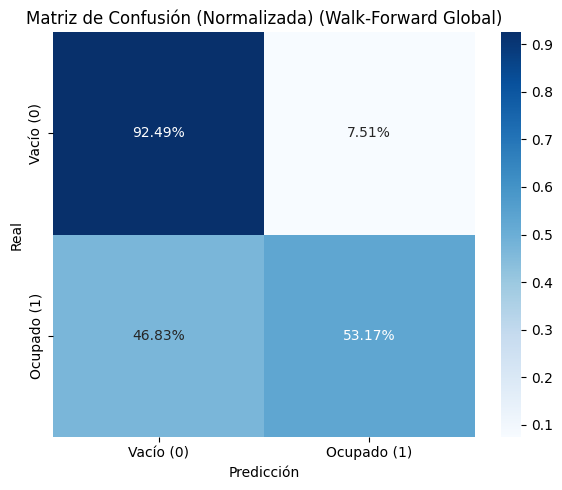

In [10]:
# 1. Cajas vacías para acumular los resultados reales y predichos de todos los meses
y_val_global = []
y_pred_global = []

# Guardar resultados de cada pliegue
for i, (train_idx, val_idx) in enumerate(folds):
    
    # --- E. Evaluación ---
    y_prob = modelo_xgb.predict_proba(X_val_tree)[:, 1]
    y_pred = modelo_xgb.predict(X_val_tree)
    
    y_val_global.extend(y_val.values)
    y_pred_global.extend(y_pred)

plot_confusion_matrix(
    np.array(y_val_global), 
    np.array(y_pred_global), 
    title_suffix="(Walk-Forward Global)")

# 3. Feature importance

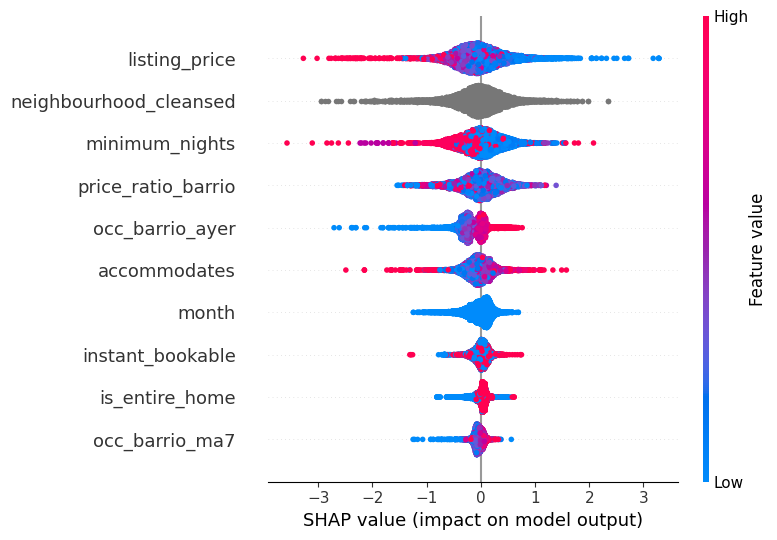

In [11]:
X_sample = X_val_tree.sample(10000, random_state=42)

explainer = shap.TreeExplainer(modelo_xgb)
shap_values = explainer(X_sample,check_additivity=False)

shap.summary_plot(shap_values.values, X_sample)

# VALIDACION DE QUE NO HAY DATA LEAKAGE FUTURO

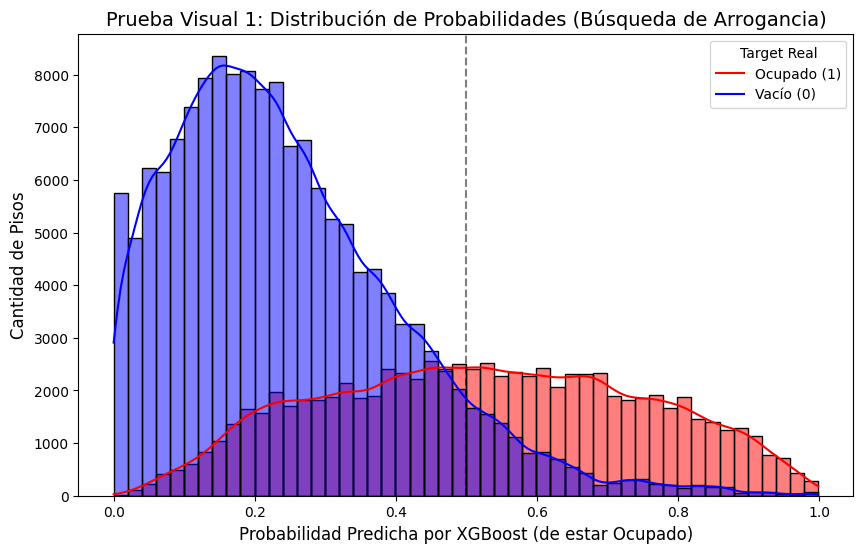

In [12]:
plt.figure(figsize=(10, 6))
# Usamos y_val_global y y_pred_global (o los del último fold: y_val, y_prob)
sns.histplot(x=y_prob, hue=y_val, bins=50, kde=True, palette={0: 'blue', 1: 'red'})
plt.title('Prueba Visual 1: Distribución de Probabilidades (Búsqueda de Arrogancia)', fontsize=14)
plt.xlabel('Probabilidad Predicha por XGBoost (de estar Ocupado)', fontsize=12)
plt.ylabel('Cantidad de Pisos', fontsize=12)
plt.axvline(0.5, color='black', linestyle='--', alpha=0.5)
plt.legend(title='Target Real', labels=['Ocupado (1)', 'Vacío (0)'])
plt.show()